In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
BASE_PATH = Path("../data/processed/new_processed")

REPORT_PATH = Path("../reports")
CHART_PATH = REPORT_PATH / "python_charts"

CHART_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
funds = pd.read_csv(BASE_PATH / "clean_fund_master.csv")

nav = pd.read_csv(
    BASE_PATH / "clean_nav_history.csv",
    parse_dates=["date"]
)

benchmark = pd.read_csv(
    BASE_PATH / "clean_benchmark.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    BASE_PATH / "clean_performance.csv"
)

print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [4]:
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
returns_df = nav.copy()

returns_df.to_csv(
    BASE_PATH / "returns_computed.csv",
    index=False
)

print("returns_computed.csv saved")

returns_computed.csv saved


In [7]:
annual_returns = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.dropna(subset=["daily_return"])

    n = len(grp)

    ann_return = (
        (1 + grp["daily_return"]).prod()
    ) ** (252 / n) - 1

    annual_returns.append(
        [code, ann_return]
    )

annual_returns = pd.DataFrame(
    annual_returns,
    columns=[
        "amfi_code",
        "annualized_return"
    ]
)

annual_returns.head()

,amfi_code,annualized_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [8]:
def calculate_cagr(df, years):

    trading_days = years * 252

    if len(df) < trading_days:
        return np.nan

    start_nav = df.iloc[-trading_days]["nav"]
    end_nav = df.iloc[-1]["nav"]

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    return cagr

In [9]:
cagr_data = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    cagr_1 = calculate_cagr(grp, 1)
    cagr_3 = calculate_cagr(grp, 3)
    cagr_5 = calculate_cagr(grp, 5)

    cagr_data.append(
        [code, cagr_1, cagr_3, cagr_5]
    )

cagr_report = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

cagr_report.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [10]:
cagr_report.to_csv(
    BASE_PATH / "cagr_report.csv",
    index=False
)

print("cagr_report.csv saved")

cagr_report.csv saved


In [11]:
RISK_FREE_RATE = 0.065

In [12]:
sharpe_list = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) == 0:
        continue

    excess_return = (
        returns.mean() * 252
    ) - RISK_FREE_RATE

    volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe = excess_return / volatility

    sharpe_list.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [13]:
sharpe_df.to_csv(
    BASE_PATH / "sharpe_values.csv",
    index=False
)

In [14]:
sortino_list = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) == 0:
        continue

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean() * 252
    )

    sortino = (
        annual_return - RISK_FREE_RATE
    ) / downside_std

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [15]:
sortino_df.to_csv(
    BASE_PATH / "sortino_values.csv",
    index=False
)

In [21]:
benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [22]:
alpha_beta = []

for code, grp in nav.groupby("amfi_code"):

    merged = pd.merge(
        grp[["date", "daily_return"]],
        benchmark[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 50:
        continue

    slope, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append(
        [code, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [23]:
alpha_beta_df.to_csv(
    BASE_PATH / "alpha_beta.csv",
    index=False
)

In [24]:
drawdowns = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    running_max = grp["nav"].cummax()

    drawdown = (
        grp["nav"] /
        running_max
    ) - 1

    max_dd = drawdown.min()

    drawdowns.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [25]:
drawdown_df.to_csv(
    BASE_PATH / "max_drawdown.csv",
    index=False
)

In [26]:
scorecard = (
    cagr_report
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(drawdown_df)
)

In [27]:
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [28]:
scorecard["fund_score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.25 * scorecard["dd_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.145807,0.312786,NaN,1.448291,0.269107,0.010472,-0.112657,4.0,1.0,6.0,8.0,4.65
30,120843,0.284811,0.256619,NaN,1.306744,0.273211,-0.004370,-0.129740,10.0,2.0,5.0,13.0,7.75
3,101206,0.450939,0.325286,NaN,1.027213,0.214656,-0.000067,-0.112916,3.0,9.0,13.0,9.0,8.00
2,100033,0.477346,0.336292,NaN,1.093699,0.268752,0.024097,-0.162172,2.0,7.0,7.0,20.0,8.75
24,120504,0.115007,0.283698,NaN,1.026524,0.216091,-0.026139,-0.125883,6.0,10.0,11.0,12.0,9.50
25,120505,0.303534,0.302065,NaN,1.180101,0.295085,-0.017454,-0.181885,5.0,5.0,3.0,25.0,9.60
19,119551,0.488839,0.277274,NaN,1.208267,0.234544,-0.025189,-0.150124,8.0,4.0,10.0,17.0,9.65
36,148569,0.444657,0.233171,NaN,1.234930,0.280803,0.017641,-0.163967,13.0,3.0,4.0,21.0,10.70
16,119094,0.309182,0.360660,NaN,0.998231,0.262732,-0.028729,-0.209609,1.0,11.0,9.0,28.0,11.85
38,149323,0.223056,0.242425,NaN,1.132122,0.265733,0.001259,-0.172481,12.0,6.0,8.0,22.0,12.20


In [29]:
scorecard.to_csv(
    BASE_PATH / "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


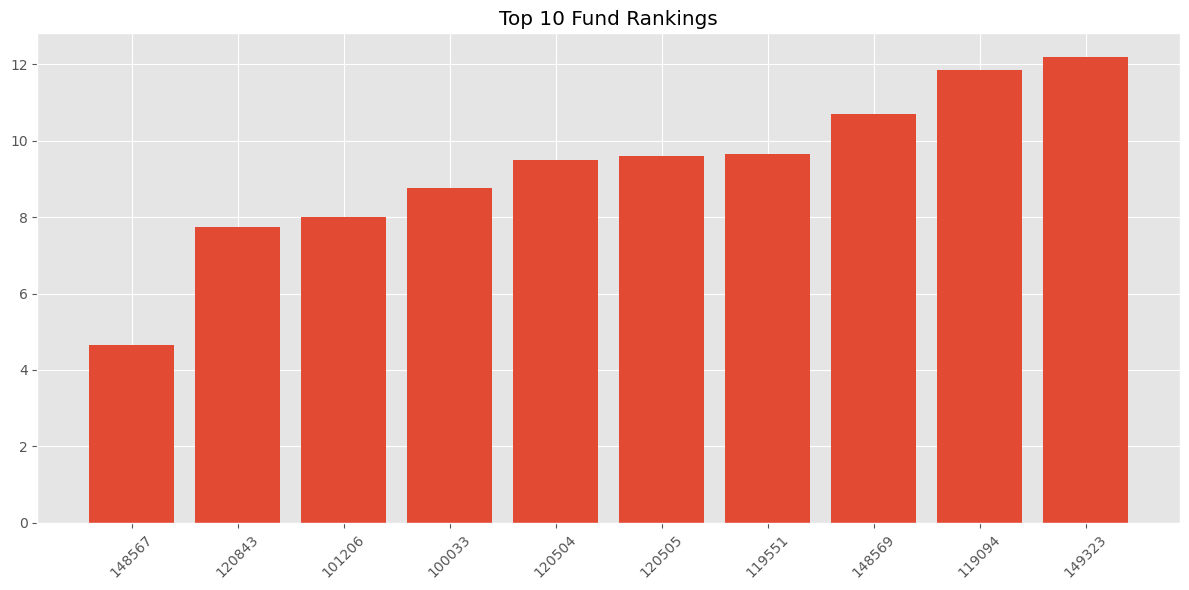

In [30]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["fund_score"]
)

plt.title("Top 10 Fund Rankings")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    CHART_PATH /
    "top10_fund_rankings.png",
    dpi=300
)

plt.show()

In [31]:
top5_codes = (
    scorecard.head(5)
    ["amfi_code"]
    .tolist()
)

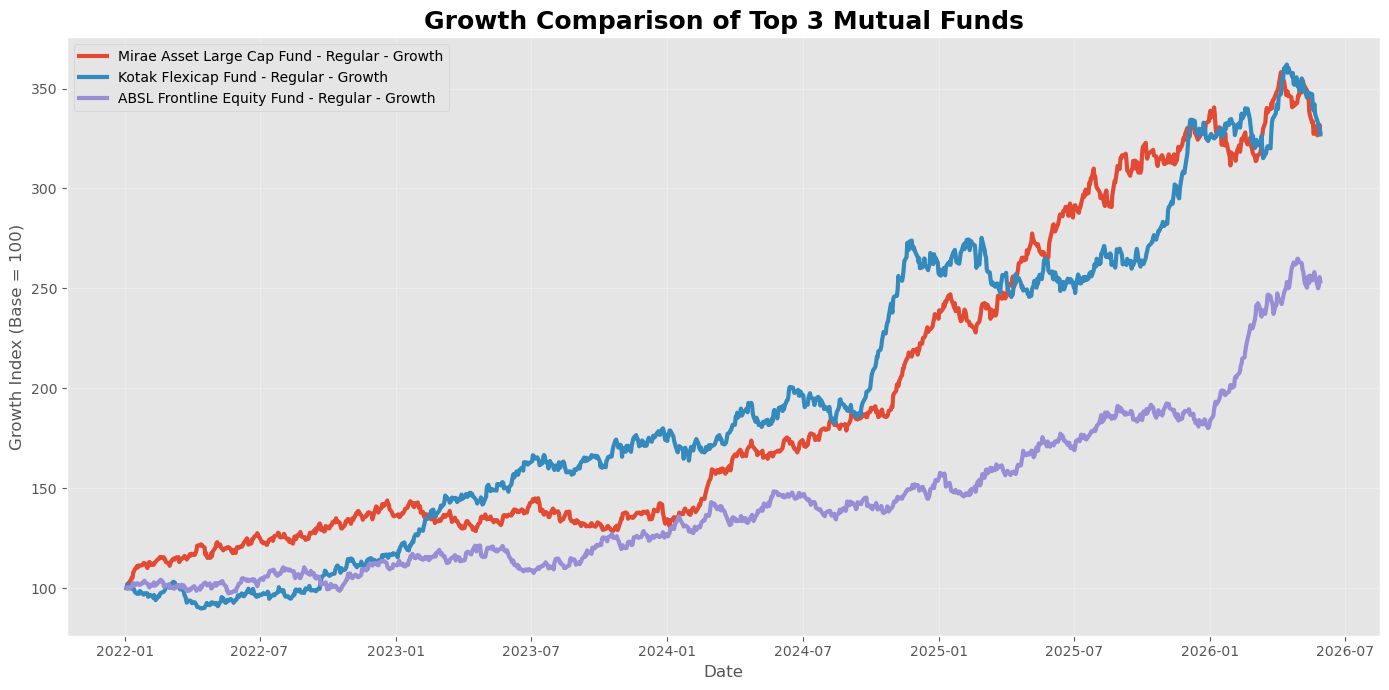

In [38]:
plt.figure(figsize=(14,7))

top3_codes = scorecard.head(3)["amfi_code"].tolist()

for code in top3_codes:

    fund = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    growth = (
        fund["nav"] /
        fund["nav"].iloc[0]
    ) * 100

    fund_name = funds.loc[
        funds["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        fund["date"],
        growth,
        linewidth=3,
        label=fund_name
    )

plt.title(
    "Growth Comparison of Top 3 Mutual Funds",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Growth Index (Base = 100)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    CHART_PATH / "top3_funds_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
final_metrics = (
    scorecard
    .merge(funds, on="amfi_code", how="left")
)

final_metrics.to_csv(
    BASE_PATH / "final_performance_metrics.csv",
    index=False
)

print("Notebook 04 Completed Successfully")

Notebook 04 Completed Successfully
